In [ ]:
import tifffile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import distance_transform_edt
from skimage.feature import peak_local_max
from skimage.filters import threshold_li, threshold_triangle
from skimage.segmentation import expand_labels, watershed
from skimage.measure import label, regionprops_table, regionprops
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
import warnings
warnings.filterwarnings("ignore")
from skimage.exposure import rescale_intensity
import matplotlib.gridspec as gridspec

In [19]:
def segment_circles(crop, min_dist = 4):
    """Threshold + watershed circles within a device crop."""
    rescaled = rescale_intensity(crop.astype(float), out_range=(0, 255))
    circles = rescaled > threshold_li(rescaled)

    labelled = label(circles)
    coords = peak_local_max(rescaled, min_distance=min_dist)
    markers = np.zeros(rescaled.shape, dtype=np.uint32)
    markers[tuple(np.round(coords).astype(int).T)] = np.arange(len(coords)) + 1
    segmetned_circles = expand_labels(watershed(-rescaled, markers, mask=labelled > 0), distance=1)
    return segmetned_circles, rescaled

In [ ]:
def fit_uniform_grid(values, k, s_min, s_max, n_s=200, n_iter=20):
    """Fit k evenly-spaced grid positions o, o+s, ..., o+(k-1)s to 1-D `values`.

    Blanks are fine: each value snaps to its nearest grid index in 0..k-1 and we
    minimise the total squared residual over (s, o). Grid-search s, then refine
    (s, o) by least squares given current index assignments.
    """
    values = np.asarray(values, dtype=float)
    best = (np.inf, None, None)
    for s in np.linspace(s_min, s_max, n_s):
        o = float(values.min())
        for n in range(n_iter):
            idx = np.clip(np.round((values - o) / s).astype(int), 0, k - 1)
            A = np.column_stack([np.ones_like(idx, dtype=float), idx.astype(float)])
            (o_new, s_new), *n = np.linalg.lstsq(A, values, rcond=None)
            if abs(o_new - o) < 1e-6 and abs(s_new - s) < 1e-6:
                o, s = o_new, s_new
                break
            o, s = o_new, s_new
        idx = np.clip(np.round((values - o) / s).astype(int), 0, k - 1)
        resid = float(np.sum((values - (o + idx * s)) ** 2))
        if resid < best[0]:
            best = (resid, s, o)
    n, s, o = best
    return o + np.arange(k) * s, s, o


In [ ]:
def rotate(ys, xs, t, cy0, cx0):
    """Rotate (ys, xs) by angle t (radians) about (cy0, cx0)."""
    cos_t, sin_t = np.cos(t), np.sin(t)
    yr = cy0 + cos_t * (ys - cy0) + sin_t * (xs - cx0)
    xr = cx0 - sin_t * (ys - cy0) + cos_t * (xs - cx0)
    return yr, xr

In [ ]:
def fit_rotated_uniform_grid(ys, xs, H, W, k=8,
                             theta_range_deg=(-30, 30), n_theta=61,
                             s_frac_range=(0.07, 0.18)):
    """Fit a rotated k×k uniform grid to spot centroids in a crop of shape (H, W).

    Searches rotation angle theta, then for each theta fits independent
    1-D uniform grids along the rotated y' and x' axes. Returns the angle
    + 1-D grid parameters (in rotated pixel coords) + the rotation centre.
    """
    ys = np.asarray(ys, dtype=float)
    xs = np.asarray(xs, dtype=float)
    centre_y, centre_x = H / 2.0, W / 2.0
    extent = max(H, W)
    s_min, s_max = s_frac_range[0] * extent, s_frac_range[1] * extent

    best = (np.inf, 0.0, None, None, None, None)
    for theta_deg in np.linspace(theta_range_deg[0], theta_range_deg[1], n_theta):
        angle_rad = np.radians(theta_deg)
        y_rot, x_rot = rotate(ys, xs, angle_rad, centre_y, centre_x)
        _, spacing_y, offset_y = fit_uniform_grid(y_rot, k, s_min, s_max, n_s=60)
        _, spacing_x, offset_x = fit_uniform_grid(x_rot, k, s_min, s_max, n_s=60)
        row_idx = np.clip(np.round((y_rot - offset_y) / spacing_y).astype(int), 0, k - 1)
        col_idx = np.clip(np.round((x_rot - offset_x) / spacing_x).astype(int), 0, k - 1)
        resid = float(np.sum((y_rot - (offset_y + row_idx * spacing_y)) ** 2 +
                             (x_rot - (offset_x + col_idx * spacing_x)) ** 2))
        if resid < best[0]:
            best = (resid, angle_rad, spacing_y, offset_y, spacing_x, offset_x)
    _, angle_rad, spacing_y, offset_y, spacing_x, offset_x = best
    return {"angle_rad": angle_rad,
            "spacing_y": spacing_y, "offset_y": offset_y,
            "spacing_x": spacing_x, "offset_x": offset_x,
            "centre_y": centre_y, "centre_x": centre_x,
            "row_centres_rot": offset_y + np.arange(k) * spacing_y,
            "col_centres_rot": offset_x + np.arange(k) * spacing_x}


In [ ]:
def sort_props_book_order(props, row_tol_frac=0.5):
    """Sort regionprops left-to-right, top-to-bottom (reading order).
    Clusters centroids into rows based on y coordinate, then sorts each row by x coordinate.
    Allow a tolerance derived from the median equivalent diameter to avoid scrambling order due to small vertical jitter within a row.
    """
    if not props:
        return []
    diameters = [prop.equivalent_diameter for prop in props]
    tol = max(1.0, np.median(diameters) * row_tol_frac)

    by_y = sorted(props, key=lambda prop: prop.centroid[0])
    rows, current = [], [by_y[0]]
    for prop in by_y[1:]:
        if prop.centroid[0] - current[-1].centroid[0] <= tol:
            current.append(prop)
        else:
            rows.append(current)
            current = [prop]
    rows.append(current)

    ordered = []
    for row in rows:
        ordered.extend(sorted(row, key=lambda prop: prop.centroid[1]))
    return ordered


In [ ]:
def identify_devices_and_quantify(folder, image_name, grid_size=8):
    test_image = tifffile.imread(os.path.join(folder, f"{image_name}.Tif"))

    device_mask = test_image > threshold_triangle(test_image)

    # Distance-transform watershed: split any merged/touching devices.
    # We expect 4 roughly square devices, so seed the watershed with up to
    # ~4 well-separated local maxima of the distance transform.
    dist_transform = distance_transform_edt(device_mask)
    # min_distance is large (~half a device width) so we don't oversplit a single square
    min_sep = int(max(20, 0.4 * np.sqrt(device_mask.sum() / 4)))
    peak_coords = peak_local_max(dist_transform, min_distance=min_sep, labels=label(device_mask))
    seed_markers = np.zeros(device_mask.shape, dtype=np.int32)
    seed_markers[tuple(peak_coords.T)] = np.arange(1, len(peak_coords) + 1)
    labelled_devices_raw = watershed(-dist_transform, seed_markers, mask=device_mask)

    fig, ax = plt.subplots()
    ax.imshow(labelled_devices_raw)
    ax.set_title(f"watershed-split devices ({labelled_devices_raw.max()} found)")

    # Keep only the 4 largest regions, reindex 1-4 L->R, T->B
    props_all = regionprops(labelled_devices_raw)
    top4 = sorted(props_all, key=lambda prop: prop.area, reverse=True)[:4]
    top4_sorted = sort_props_book_order(top4)

    label_map = np.zeros(labelled_devices_raw.max() + 1, dtype=labelled_devices_raw.dtype)
    for new_label, prop in enumerate(top4_sorted, start=1):
        label_map[prop.label] = new_label
    labelled_devices = label_map[labelled_devices_raw]

    device_ids = [device_id for device_id in sorted(np.unique(labelled_devices)) if device_id != 0]
    n_devices = len(device_ids)

    # --- Pass 1: segment each device and fit its OWN rotated grid ---
    device_results = {}
    for dev_id in device_ids:
        minr, minc, maxr, maxc = regionprops((labelled_devices == dev_id).astype(int))[0].bbox
        crop = test_image[minr:maxr, minc:maxc]
        segmented_circles, rescaled = segment_circles(crop, min_dist=4)
        H, W = segmented_circles.shape

        centroids = {prop.label: (prop.centroid[0], prop.centroid[1]) for prop in regionprops(segmented_circles)}
        ys = np.array([coords[0] for coords in centroids.values()])
        xs = np.array([coords[1] for coords in centroids.values()])

        fit = fit_rotated_uniform_grid(ys, xs, H, W, k=grid_size)
        angle_rad = fit["angle_rad"]
        spacing_y, offset_y = fit["spacing_y"], fit["offset_y"]
        spacing_x, offset_x = fit["spacing_x"], fit["offset_x"]
        centre_y, centre_x = fit["centre_y"], fit["centre_x"]
        print(f"device {dev_id}: angle={np.degrees(angle_rad):+.2f}deg | "
              f"row spacing={spacing_y:.1f} offset={offset_y:.1f} | "
              f"col spacing={spacing_x:.1f} offset={offset_x:.1f}")

        # Remap each circle to its (row, col) cell using rotated coords
        local_lmap = np.zeros(segmented_circles.max() + 1, dtype=np.int32)
        used = {}  # cell_id -> (local_id, match_dist)
        for local_id, (centroid_y, centroid_x) in centroids.items():
            y_rot, x_rot = rotate(np.array([centroid_y]), np.array([centroid_x]),
                                  angle_rad, centre_y, centre_x)
            y_rot, x_rot = float(y_rot[0]), float(x_rot[0])
            row_idx = int(np.clip(round((y_rot - offset_y) / spacing_y), 0, grid_size - 1))
            col_idx = int(np.clip(round((x_rot - offset_x) / spacing_x), 0, grid_size - 1))
            cell_id = row_idx * grid_size + col_idx + 1  # 1..grid_size², position A1 == 1
            match_dist = np.hypot((offset_y + row_idx * spacing_y) - y_rot,
                                  (offset_x + col_idx * spacing_x) - x_rot)
            if cell_id in used and used[cell_id][1] <= match_dist:
                continue
            if cell_id in used:
                local_lmap[used[cell_id][0]] = 0
            used[cell_id] = (local_id, match_dist)
            local_lmap[local_id] = cell_id
        # Unmatched circles get fresh IDs above grid_size²
        next_id = grid_size * grid_size + 1
        for local_id in centroids:
            if local_lmap[local_id] == 0:
                local_lmap[local_id] = next_id
                next_id += 1

        device_results[dev_id] = {
            "crop": crop, "rescaled": rescaled, "seg": local_lmap[segmented_circles],
            "fit": fit,
        }

    # --- Pool spot detections across devices ---
    union_cells = set()
    spacings = []
    for dev_id in device_ids:
        seg_pre = device_results[dev_id]["seg"]
        for prop in regionprops(seg_pre):
            if 1 <= prop.label <= grid_size * grid_size:
                union_cells.add(int(prop.label))
        fit_device = device_results[dev_id]["fit"]
        spacings.append(min(fit_device["spacing_y"], fit_device["spacing_x"]))
    spot_r = float(np.min(spacings)) / 2.0 if spacings else 5.0
    print(f"pooled intersections: {len(union_cells)} / {grid_size * grid_size} | spot radius: {spot_r:.1f}px")

    for dev_id in device_ids:
        res = device_results[dev_id]
        fit = res["fit"]
        H, W = res["seg"].shape
        angle_rad = fit["angle_rad"]
        centre_y, centre_x = fit["centre_y"], fit["centre_x"]
        cos_angle, sin_angle = np.cos(angle_rad), np.sin(angle_rad)
        new_seg = np.zeros((H, W), dtype=np.int32)
        yy, xx = np.ogrid[:H, :W]
        for cell in union_cells:
            row_idx = (cell - 1) // grid_size
            col_idx = (cell - 1) % grid_size
            y_rot_centre = fit["offset_y"] + row_idx * fit["spacing_y"]
            x_rot_centre = fit["offset_x"] + col_idx * fit["spacing_x"]
            disk_centre_y = centre_y + cos_angle * (y_rot_centre - centre_y) - sin_angle * (x_rot_centre - centre_x)
            disk_centre_x = centre_x + sin_angle * (y_rot_centre - centre_y) + cos_angle * (x_rot_centre - centre_x)
            disk_mask = (yy - disk_centre_y) ** 2 + (xx - disk_centre_x) ** 2 <= spot_r ** 2
            new_seg[disk_mask] = cell
        res["seg"] = new_seg

    # --- Plot: 3-row figure ---
    fig = plt.figure(figsize=(5 * n_devices, 15))
    gs = gridspec.GridSpec(3, n_devices, figure=fig, height_ratios=[1, 1, 1])

    ax_raw = fig.add_subplot(gs[0, : n_devices // 2])
    ax_raw.imshow(test_image)
    ax_raw.set_title("raw image")
    ax_raw.axis("off")

    ax_dev = fig.add_subplot(gs[0, n_devices // 2 :])
    ax_dev.imshow(labelled_devices, cmap="bwr")
    for prop in regionprops(labelled_devices):
        centroid_y, centroid_x = prop.centroid
        ax_dev.text(centroid_x, centroid_y, str(prop.label), color="black", fontsize=12,
                    ha="center", va="center", fontweight="bold")
    ax_dev.set_title(f"{n_devices} devices, {grid_size}x{grid_size} grid IDs")
    ax_dev.axis("off")

    records = []
    for i, dev_id in enumerate(device_ids):
        res = device_results[dev_id]
        seg = res["seg"]
        H, W = seg.shape

        ax_overlay = fig.add_subplot(gs[1, i])
        ax_overlay.imshow(res["rescaled"], cmap="gray")
        ax_overlay.imshow(np.ma.masked_where(seg == 0, seg), cmap="bwr", alpha=0.3)
        # Draw rotated grid lines: forward-rotate endpoints from rotated frame back to image frame
        fit = res["fit"]
        angle_rad = fit["angle_rad"]
        centre_y, centre_x = fit["centre_y"], fit["centre_x"]
        cos_angle, sin_angle = np.cos(angle_rad), np.sin(angle_rad)

        def _back_rotate(y_rot, x_rot):
            y = centre_y + cos_angle * (y_rot - centre_y) - sin_angle * (x_rot - centre_x)
            x = centre_x + sin_angle * (y_rot - centre_y) + cos_angle * (x_rot - centre_x)
            return y, x

        # Extend each grid line across the device (a bit beyond the outer columns/rows)
        pad = max(fit["spacing_x"], fit["spacing_y"])
        x_rot_lo = fit["col_centres_rot"].min() - pad
        x_rot_hi = fit["col_centres_rot"].max() + pad
        y_rot_lo = fit["row_centres_rot"].min() - pad
        y_rot_hi = fit["row_centres_rot"].max() + pad
        for y_rot in fit["row_centres_rot"]:
            ys_line, xs_line = _back_rotate(np.array([y_rot, y_rot]),
                                            np.array([x_rot_lo, x_rot_hi]))
            ax_overlay.plot(xs_line, ys_line, color="lime", lw=0.4, alpha=0.7)
        for x_rot in fit["col_centres_rot"]:
            ys_line, xs_line = _back_rotate(np.array([y_rot_lo, y_rot_hi]),
                                            np.array([x_rot, x_rot]))
            ax_overlay.plot(xs_line, ys_line, color="lime", lw=0.4, alpha=0.7)
        ax_overlay.set_xlim(0, W); ax_overlay.set_ylim(H, 0)
        ax_overlay.set_title(f"device {dev_id} ({np.degrees(angle_rad):+.1f}°)")
        ax_overlay.axis("off")

        ax_lbl = fig.add_subplot(gs[2, i])
        ax_lbl.imshow(seg, cmap="bwr")
        for prop in regionprops(seg):
            centroid_y, centroid_x = prop.centroid
            ax_lbl.text(centroid_x, centroid_y, str(prop.label), color="black", fontsize=9,
                        ha="center", va="center", fontweight="bold")
        ax_lbl.set_title(f"device {dev_id} labels")
        ax_lbl.axis("off")

        df = pd.DataFrame(regionprops_table(seg, intensity_image=res["crop"],
                            properties=["label", "area", "mean_intensity"]))
        df["device_id"] = dev_id
        df["circle_id"] = df["label"]
        df["total_intensity"] = (df["mean_intensity"] * df["area"]).astype(int)
        records.append(df[["device_id", "circle_id", "total_intensity"]])

    df_circles = (pd.concat(records, ignore_index=True)
                .sort_values(["device_id", "circle_id"])
                .reset_index(drop=True))
    plt.tight_layout()
    plt.savefig(os.path.join(folder, f"{image_name}_analysis.png"), dpi=300)
    plt.show()
    df_circles.to_csv(os.path.join(folder, f"{image_name}_circle_quantification.csv"), index=False)


device 1: angle=-10.00deg | row spacing=18.2 offset=65.0 | col spacing=18.9 offset=64.4
device 2: angle=-8.00deg | row spacing=18.6 offset=67.4 | col spacing=18.9 offset=53.7
device 3: angle=+0.00deg | row spacing=18.4 offset=45.4 | col spacing=18.7 offset=40.8
device 4: angle=-28.00deg | row spacing=24.7 offset=89.9 | col spacing=19.3 offset=71.1
pooled intersections: 21 / 64 | spot radius: 9.1px


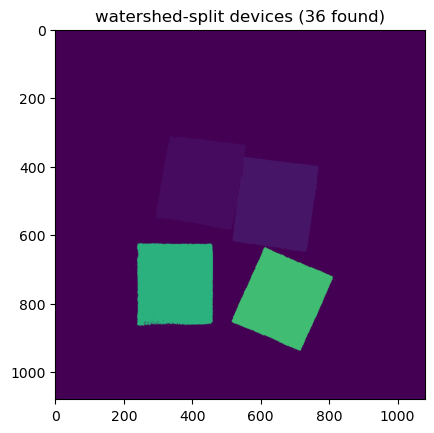

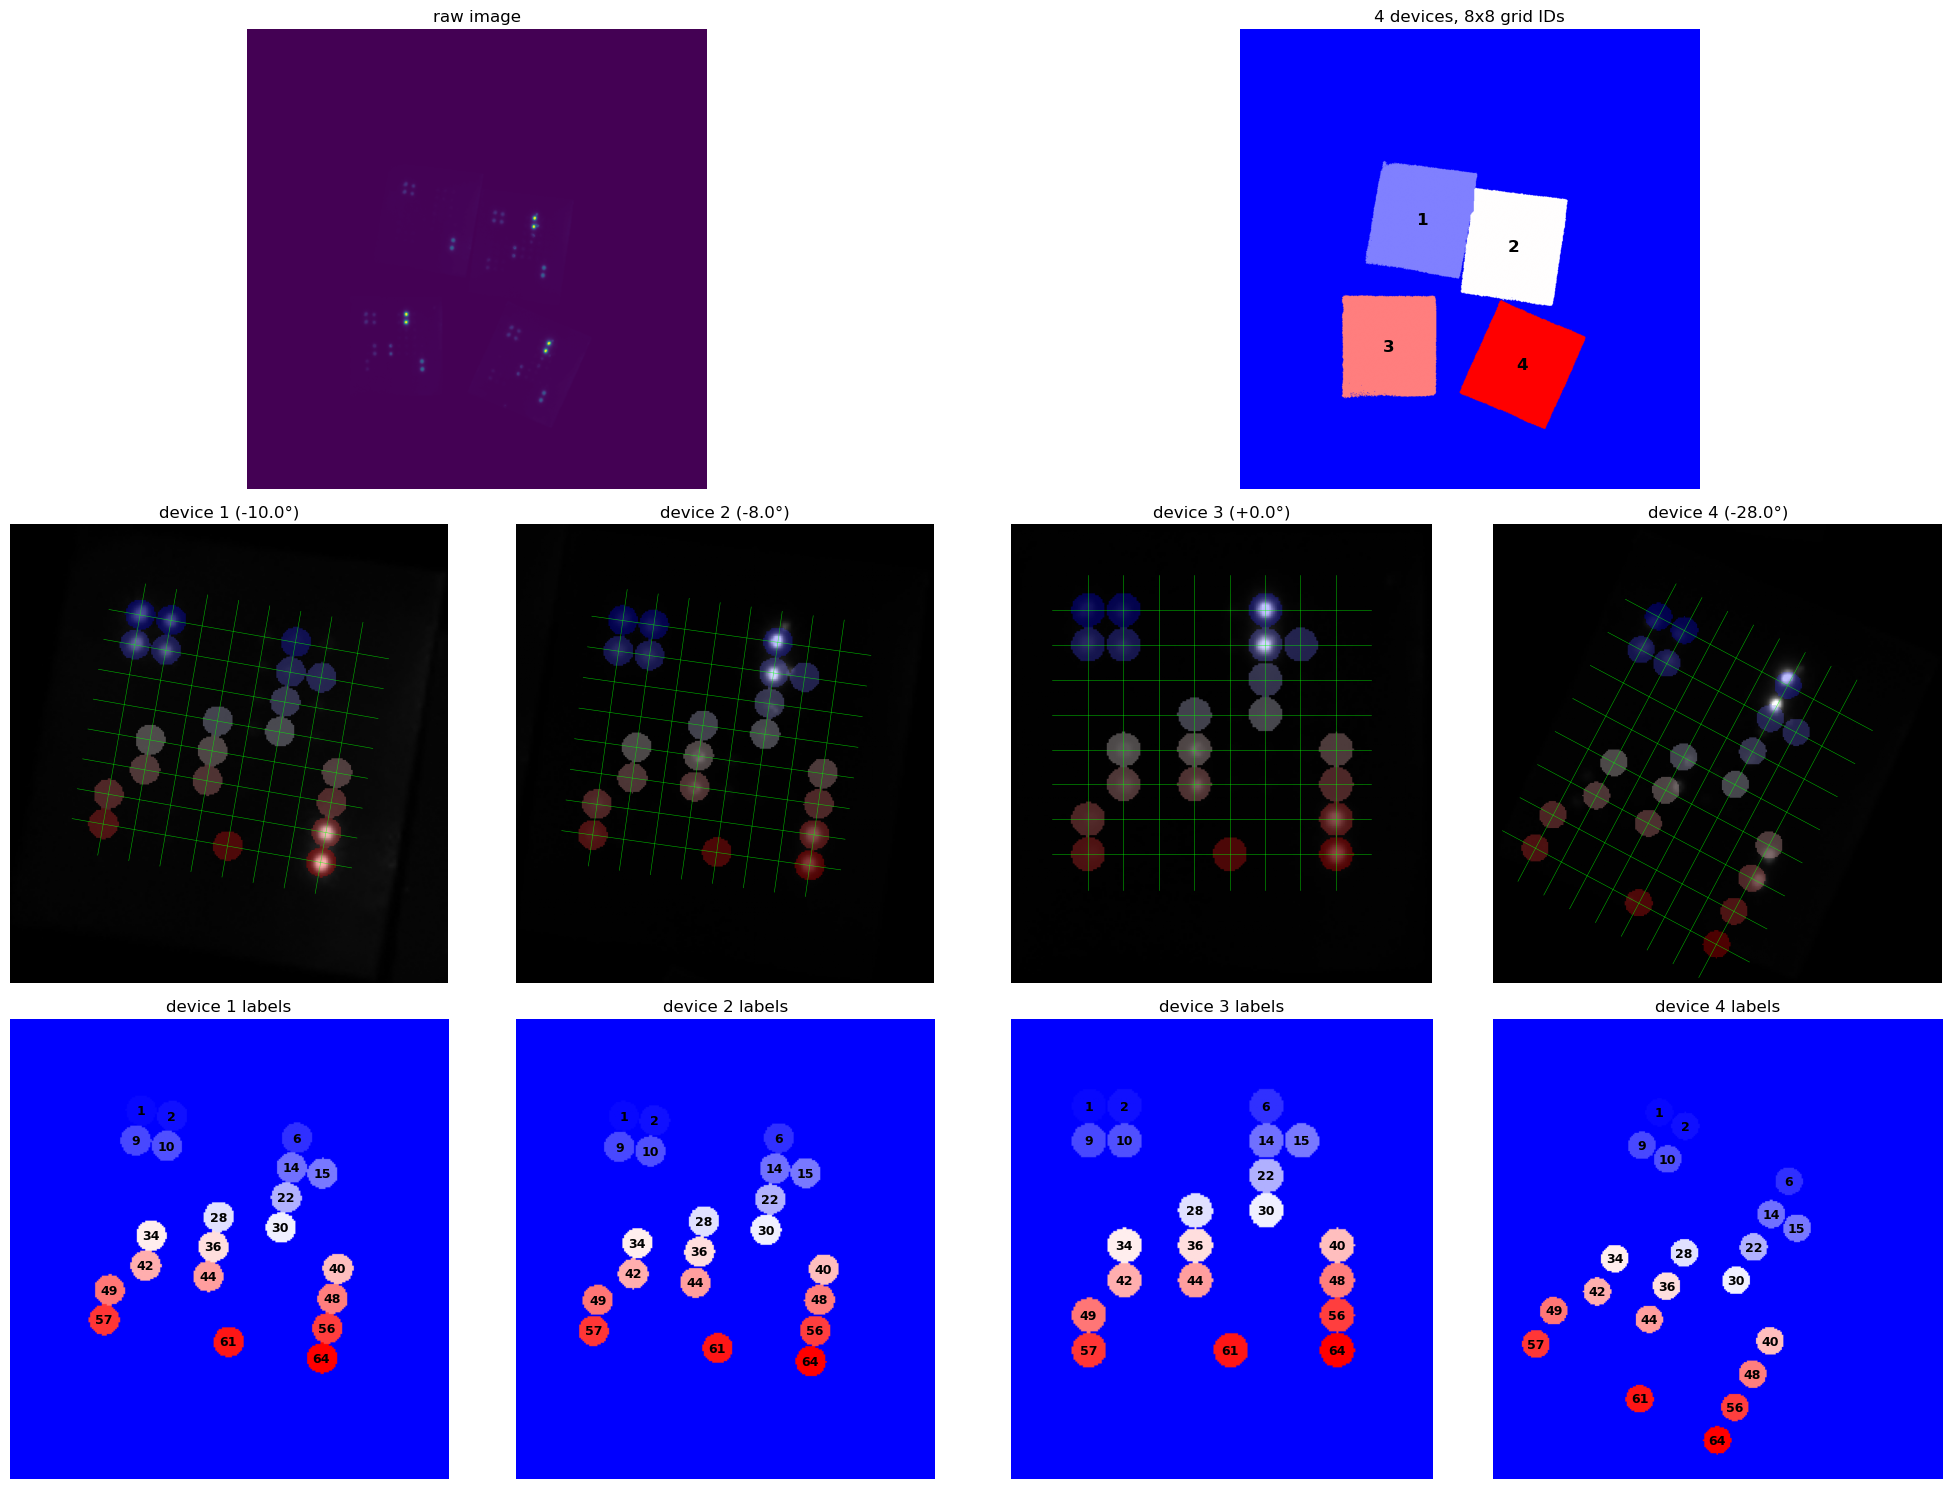

In [18]:
# folder = r"Z:\Dorota_Avalon\cytokine array\cytokine array devices\c1"
# image_name = "IM000252"
# identify_devices_and_quantify(folder, image_name)
folder = r"Z:\Dorota_Avalon\cytokine array\cytokine array devices\c2"
image_name = "IM000225"
identify_devices_and_quantify(folder, image_name)
# folder = r"Z:\Dorota_Avalon\cytokine array\Cytokine_array_FBs\Dorota\c1"
# image_name = "20250122_FB_c1_11"
# identify_devices_and_quantify(folder, image_name)

device 1: angle=-4.00deg | row spacing=11.5 offset=40.5 | col spacing=12.5 offset=29.2
device 2: angle=-2.00deg | row spacing=11.3 offset=44.0 | col spacing=12.0 offset=35.5
device 3: angle=-3.00deg | row spacing=11.8 offset=44.8 | col spacing=11.8 offset=35.6
device 4: angle=-1.00deg | row spacing=11.6 offset=42.8 | col spacing=12.0 offset=31.4
pooled intersections: 12 / 64 | spot radius: 5.6px


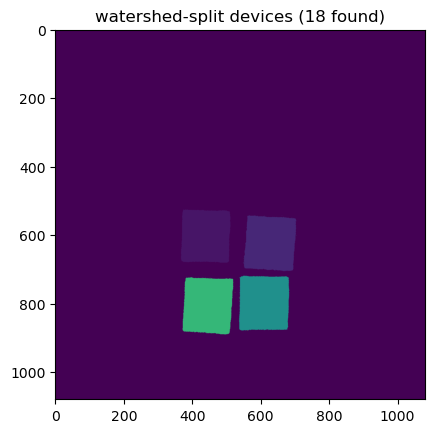

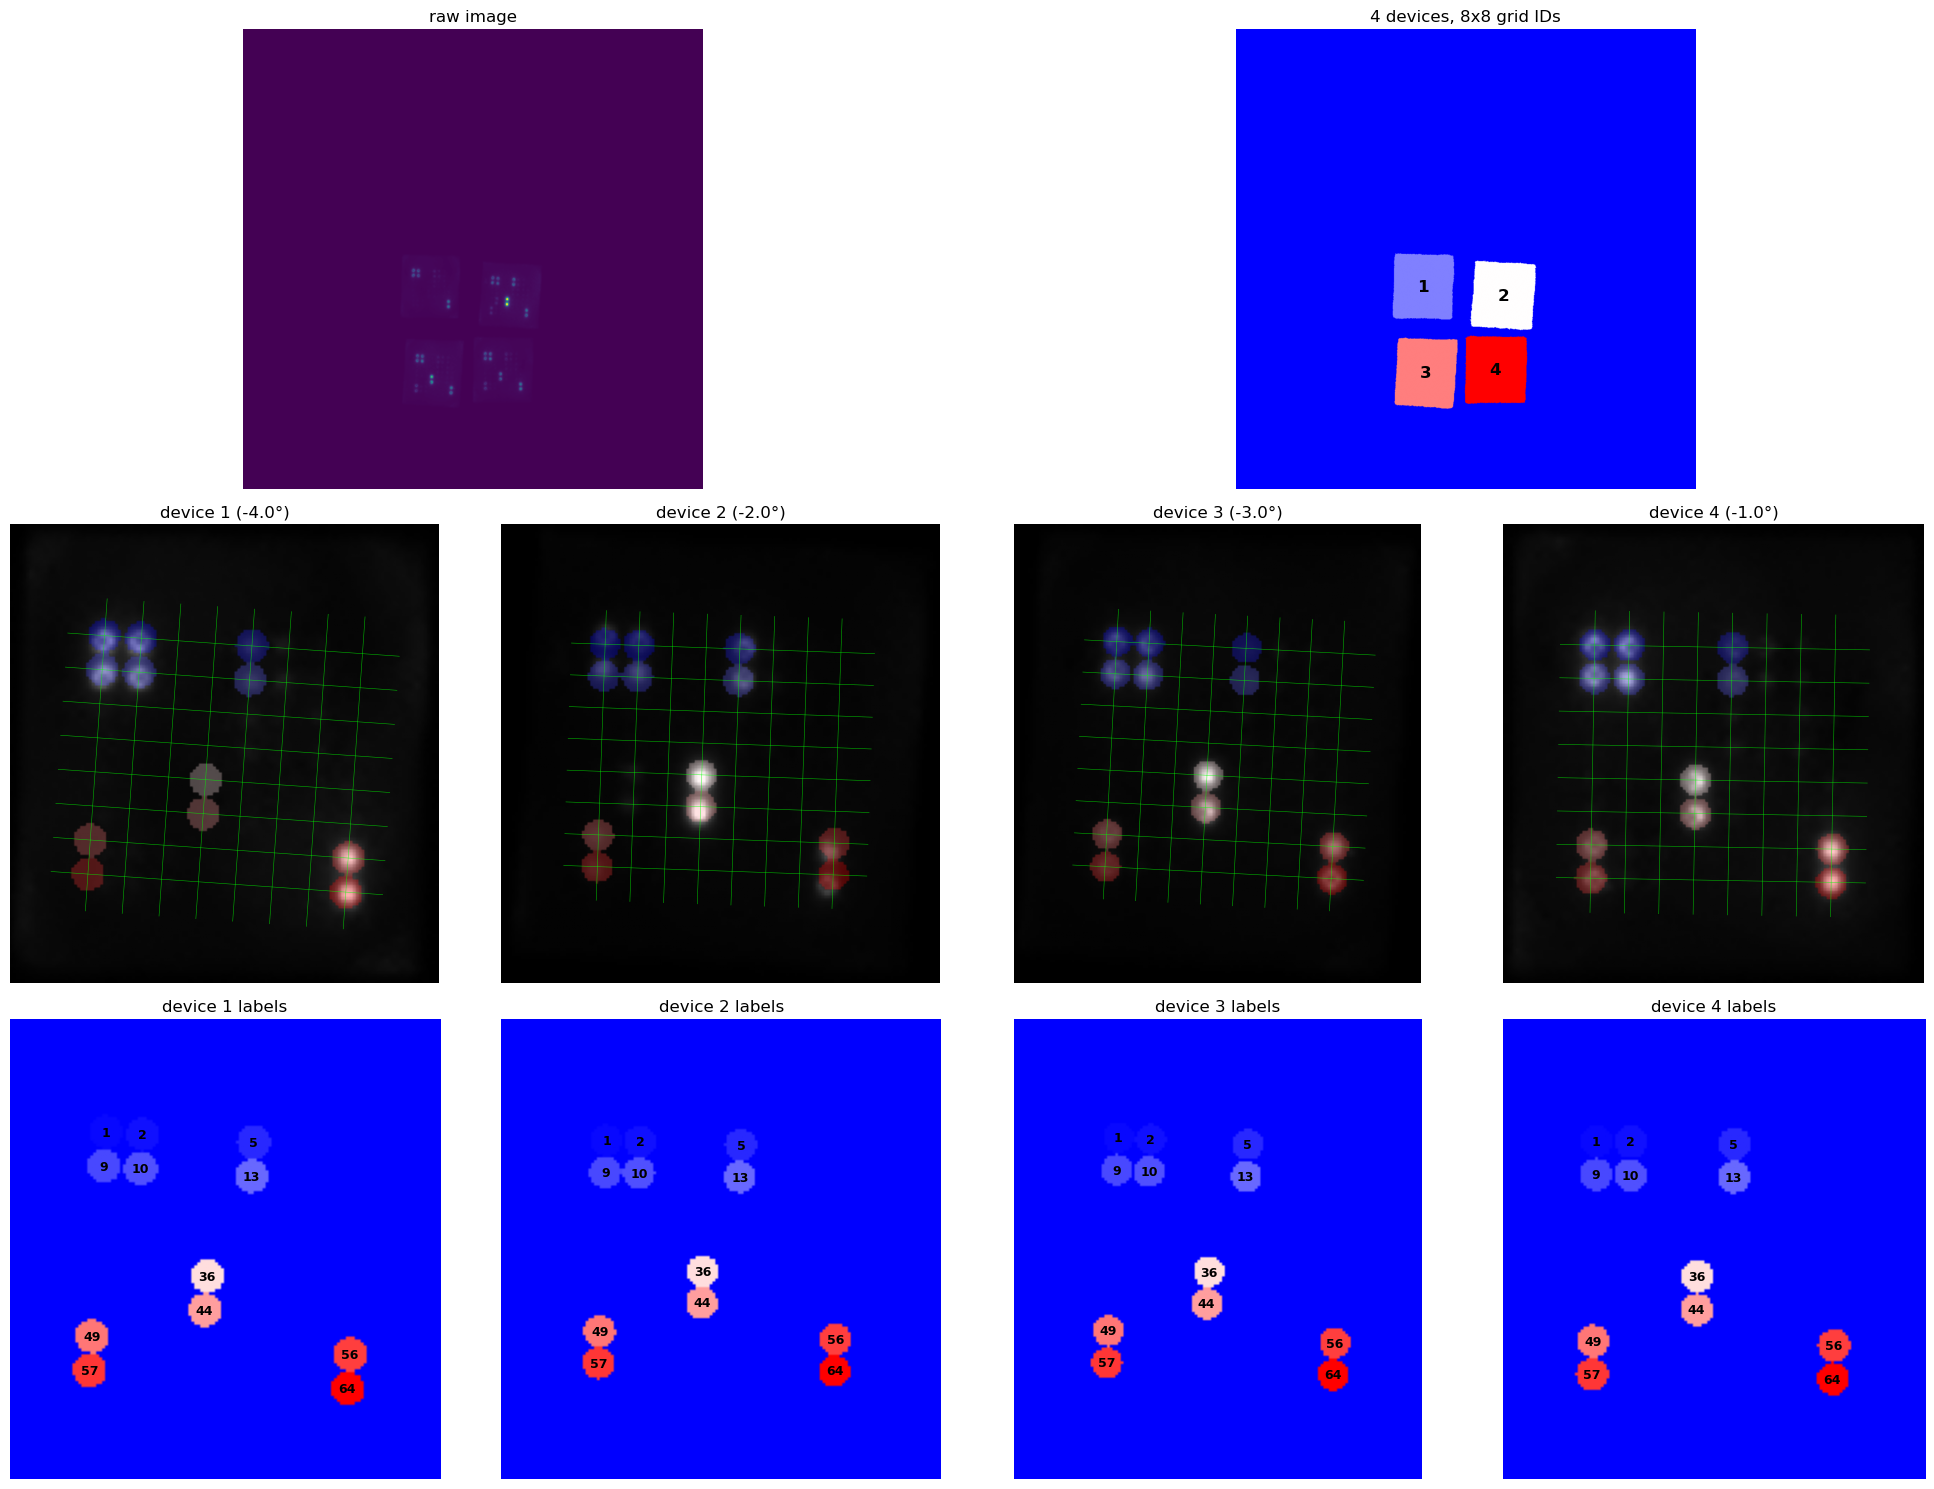

In [149]:
folder = r"Z:\Dorota_Avalon\cytokine array\Cytokine_array_FBs\Dorota\c2"
image_name = "20250122_FB_c2_13"
identify_devices_and_quantify(folder, image_name)